# MSV000093033:

The data can be found here: https://massive.ucsd.edu/ProteoSAFe/dataset.jsp?accession=MSV000093033

__Abstract__: Lorem ipsum ...

## 0. Imports & Set-Up:

In [1]:
import multiprocessing

from collections import Counter
from joblib import Parallel, delayed
from pathlib import Path
from typing import Type

from sklearn.base import ClusterMixin
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, calinski_harabasz_score, confusion_matrix, davies_bouldin_score, pairwise_distances, silhouette_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import check_random_state

from scipy.optimize import linear_sum_assignment

import umap

import numpy as np
import pandas as pd

import anndata as ad, io, gzip, os
from pyteomics import mzml
import scanpy as sc

import matplotlib.pyplot as plt

from carve import CARVE

from pathlib import Path

In [2]:
np.random.seed(42)
os.environ["PYTHONHASHSEED"] = str(42)
RANDOM_SEED = 42

In [3]:
def get_n_jobs():
    # read env override first
    env_val = os.environ.get("CARVE_N_JOBS", None)
    if env_val is not None:
        try:
            return int(env_val)
        except ValueError:
            pass 
        
    # otherwise: default = (num cores - 1)
    try:
        n_cores = multiprocessing.cpu_count()
    except NotImplementedError:
        n_cores = 4

    return max(1, n_cores - 1)

N_JOBS = get_n_jobs()
print(f"Using N_JOBS={N_JOBS} for parallel processing.")

Using N_JOBS=10 for parallel processing.


In [4]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


`gamma_quantiles` estimates reasonable RBF kernel width parameters (`gamma`) from the data using quantiles of pairwise squared distances. Useful for Spectral Clustering – scale parameter for the RBF affinity.

**Inputs**
- `X` (`np.ndarray`): Data matrix with shape (n_samples, n_features).
- `qs` (`tuple[float, ...]`, default `(0.05, 0.10, 0.25, 0.50)`): Quantiles of the upper-triangular pairwise squared distances to use.

**Process**
1. Computes the full pairwise squared Euclidean distance matrix `D2 = pairwise_distances(X, metric='sqeuclidean')`.
2. Extracts the upper-triangular (non-redundant) distances `d2`.
3. For each quantile `q` in `qs`, computes `gamma_q = 1 / (2 * quantile(d2, q))`, following the median/quantile heuristic for RBF kernels.

**Output**
- `list[float]`: A list of `gamma` values corresponding to each quantile in `qs`. Lower quantiles yield larger `gamma` (narrower kernels), higher quantiles yield smaller `gamma` (wider kernels).

In [5]:
def gamma_quantiles(X, qs=(0.05, 0.10, 0.25, 0.50)):
    """
    Estimate RBF kernel width parameters (gamma) from data using quantiles of pairwise squared distances.

    Args:
        X (np.ndarray): Data matrix with shape (n_samples, n_features).
        qs (tuple[float, ...], optional): Quantiles to use for gamma estimation. Default is (0.05, 0.10, 0.25, 0.50).

    Returns:
        list[float]: List of gamma values corresponding to each quantile in qs.
    """
    D2 = pairwise_distances(X, metric='sqeuclidean')
    d2 = D2[np.triu_indices_from(D2, k=1)]
    return [1.0 / (2.0 * np.quantile(d2, q)) for q in qs]

The following cell defines a custom `LeidenClustering` class, providing a scikit-learn style interface to the Leiden community detection algorithm. This approach enables clustering of tabular data by first constructing a k-nearest neighbor (kNN) graph and then applying Leiden for community detection.

The custom `LeidenClustering` class:
- Accepts standard sklearn parameters (`n_clusters`, `n_neighbors`, `resolution`, `random_state`).
- Builds an undirected kNN graph from the input data.
- Runs Leiden via the `leidenalg` package on the constructed graph.
- Optionally relabels clusters to match the requested number of clusters (`n_clusters`), mapping the largest clusters to consecutive labels.
- Is compatible with sklearn workflows (`fit`, `fit_predict`).

This wrapper is used for benchmarking Leiden clustering alongside other sklearn algorithms below.

In [6]:
from sklearn.base import BaseEstimator
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors

class LeidenClustering(BaseEstimator, ClusterMixin):
    """
    Wrapper for Leiden community detection algorithm with sklearn interface.
    Clusters tabular data by building a k-nearest neighbor graph and running Leiden.

    Parameters:
        n_clusters (int): Desired number of clusters (approximate, Leiden may not match exactly).
        n_neighbors (int): Number of neighbors for graph construction (default: 10).
        resolution (float): Resolution parameter for Leiden (higher = more clusters, default: 1.0).
        random_state (int or None): Random seed.
    """
    def __init__(self, n_clusters=None, n_neighbors=10, resolution=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.n_neighbors = n_neighbors
        self.resolution = resolution
        self.random_state = random_state

    def fit(self, X, y=None):
        # Build kNN graph
        knn = NearestNeighbors(n_neighbors=self.n_neighbors + 1, metric='euclidean')
        knn.fit(X)
        knn_graph = knn.kneighbors_graph(X, mode='connectivity')
        sources, targets = knn_graph.nonzero()
        edges = list(zip(sources.tolist(), targets.tolist()))

        # Create igraph graph
        g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
        g.simplify()

        # Run Leiden
        partition = leidenalg.find_partition(
            g,
            leidenalg.RBConfigurationVertexPartition,
            resolution_parameter=self.resolution,
            seed=self.random_state
        )
        self.labels_ = np.array(partition.membership)

        # Optionally, relabel to match n_clusters if specified
        if self.n_clusters is not None and len(np.unique(self.labels_)) != self.n_clusters:
            # Map largest clusters to 0..n_clusters-1, rest to -1
            counts = np.bincount(self.labels_)
            top = np.argsort(counts)[::-1][:self.n_clusters]
            mapping = {old: new for new, old in enumerate(top)}
            self.labels_ = np.array([mapping.get(l, -1) for l in self.labels_])

        return self

    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_

`align_labels` aligns arbitrary cluster labels to a set of reference labels by maximizing agreement via the Hungarian algorithm. This is useful because clustering algorithms assign label IDs arbitrarily, and direct comparison to true labels requires a permutation alignment.

**Inputs**
- `true_labels` (`np.ndarray`): Ground-truth labels for each sample (preferably integer-coded, e.g., `pd.Categorical(...).codes`).
- `pred_labels` (`np.ndarray`): Predicted cluster labels for each sample (arbitrary IDs).

**Process**
1. Computes the confusion matrix `cm` between `true_labels` and `pred_labels`.
2. Applies the Hungarian algorithm (`linear_sum_assignment`) to `-cm` to find the permutation of predicted labels that maximizes total matches.
3. Builds a mapping from predicted labels to matched true labels.
4. Re-labels `pred_labels` according to this mapping; any predicted label not present in the mapping is left unchanged.

**Output**
- `np.ndarray`: Aligned predicted labels with IDs permuted to best match `true_labels` (same shape as `pred_labels`).

In [7]:
def align_labels(true_labels, pred_labels):
    """
    Aligns predicted cluster labels to true labels by maximizing agreement using the Hungarian algorithm.

    Args:
        true_labels (np.ndarray): Ground-truth labels for each sample (integer-coded).
        pred_labels (np.ndarray): Predicted cluster labels for each sample (arbitrary IDs).

    Returns:
        np.ndarray: Aligned predicted labels with IDs permuted to best match true_labels.
    """
    cm = confusion_matrix(true_labels, pred_labels)
    
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    label_map = {old: new for old, new in zip(col_ind, row_ind)}
    return np.array([label_map[l] if l in label_map else l for l in pred_labels])

The following functions implement the **Gap Statistic** method for determining the optimal number of clusters in a dataset.  
They work together to quantify how much better the observed clustering is compared to what would be expected under a reference (null) distribution with no inherent structure.

##### Function 1: `compute_dispersion`
Computes the within-cluster dispersion measure \( W_k \), which quantifies how tightly points are grouped within each cluster.

**Inputs**
- `X` (`np.ndarray`): Data matrix with samples as rows and features as columns.  
- `labels` (`np.ndarray`): Cluster labels for each observation.  
- `metric` (`str`, default `'euclidean'`): Distance metric used to compute pairwise distances within clusters.

**Process**
1. Iterates over all unique cluster labels.  
2. For each cluster, computes all pairwise distances between points.  
3. Averages the total within-cluster distances, normalized by the number of points.  
4. Sums these values across clusters to obtain total within-cluster dispersion.

**Output**
- Returns a single float `W_k`: the total within-cluster dispersion.

##### Function 2: `gen_null`
Generates a reference dataset (null model) by independently sampling each feature from a uniform distribution spanning the observed feature range.

**Inputs**
- `X` (`np.ndarray`): Original dataset.  
- `_` (`int`): Placeholder (unused).  
- `random_state` (`int`): Seed for reproducibility.

**Process**
1. For each feature (column), samples uniformly between its observed minimum and maximum.  
2. Produces a dataset with the same shape as `X` but without clustering structure.

**Output**
- Returns `X_ref` (`np.ndarray`): Null (reference) dataset.

##### Function 3: `gap_statistic`
Computes the Gap Statistic comparing observed clustering dispersion to that expected under the null model.

**Inputs**
- `X` (`np.ndarray`): Data matrix.  
- `labels` (`np.ndarray`): Cluster labels from a fitted clustering algorithm.  
- `metric` (`str`, default `'euclidean'`): Distance metric for dispersion calculation.  
- `n_refs` (`int`, default `10`): Number of reference datasets to generate.  
- `algorithm` (`Type[ClusterMixin]`, default `KMeans`): Clustering algorithm used for reference clustering.  
- `random_state` (`int` or `None`): Random seed for reproducibility.

**Process**
1. Computes observed within-cluster dispersion `W_k`.  
2. Generates `n_refs` null datasets via `gen_null`.  
3. Clusters each null dataset and computes its log-dispersion.  
4. Estimates the expected log-dispersion under the null model.  
5. Computes the Gap Statistic:  
   $$
   \text{Gap}(k) = E[\log(W_k^{\text{null}})] - \log(W_k)
   $$
   Larger gaps indicate more distinct clustering structure than expected by chance.

**Output**
- Returns a single float `gap`: the computed Gap Statistic value for the given clustering configuration.


In [8]:
def compute_dispersion(X: np.ndarray, labels: np.ndarray, metric: str = 'euclidean') -> float:
    """
    Computes the within-cluster dispersion measure W_k for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').

    Returns:
        float: Total within-cluster dispersion W_k.
    """
    unique_labels = np.unique(labels)
    W_k = 0.0
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        
        if len(cluster_points) <= 1:
            continue
        
        distances = pairwise_distances(cluster_points, metric=metric, squared=True)
        W_k += np.sum(distances) / (2 * cluster_points.shape[0])
    
    return W_k

def gen_null(X: np.ndarray, random_state: int) -> np.ndarray:
    """
    Generates a reference (null) dataset by sampling each feature independently
    from a uniform distribution spanning the observed feature range.

    Args:
        X (np.ndarray): Original dataset.
        random_state (int): Seed for reproducibility.

    Returns:
        np.ndarray: Null (reference) dataset of same shape as X.
    """
    rng = check_random_state(random_state)
    n_samples, p = X.shape
    
    X_ref = np.empty_like(X)
    for j in range(p):
        X_ref[:, j] = rng.uniform(np.min(X[:, j]), np.max(X[:, j]), size=n_samples)
        
    return X_ref

def gap_statistic(
    X: np.ndarray, 
    labels: np.ndarray, 
    metric: str = 'euclidean', 
    n_refs: int = 10, 
    algorithm: Type[ClusterMixin] = KMeans, 
    random_state: str = None
) -> float:
    """
    Computes the Gap Statistic for a clustering solution, comparing observed within-cluster dispersion
    to that expected under a null reference distribution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.
        metric (str): Distance metric used to compute pairwise distances within clusters (default: 'euclidean').
        n_refs (int): Number of reference datasets to generate (default: 10).
        algorithm (Type[ClusterMixin]): Clustering algorithm used for reference clustering (default: KMeans).
        random_state (str or None): Random seed for reproducibility.

    Returns:
        float: Computed Gap Statistic value for the given clustering configuration.
    """
    num_cores = N_JOBS
    
    rng = check_random_state(random_state)
    W_k = compute_dispersion(X, labels, metric)
    
    # generate and cluster null-models
    def _compute_ref_disp(i: int) -> float:
        X_ref = gen_null(X, rng.randint(0, 1e6))

        k = len(np.unique(labels))
        model = algorithm(n_clusters=k)
        ref_labels = model.fit_predict(X_ref)

        return np.log(compute_dispersion(X_ref, ref_labels, metric))

    ref_log_disps = Parallel(n_jobs=num_cores)(
        delayed(_compute_ref_disp)(i) for i in range(n_refs)
    )
        
    log_W_k = np.log(W_k)
    log_w_k_ref = np.mean(ref_log_disps)
    
    gap = log_w_k_ref - log_W_k
    return gap

`davies_bouldin_inv` computes a normalized, "higher-is-better" variant of the Davies–Bouldin index for a given clustering. It transforms the standard Davies–Bouldin score `db` into

$$
\frac{1}{1 + \textit{Davies–Bouldin Index}}
$$

, so tighter, well-separated clusters yield values closer to 1, while worse clusterings approach 0.

##### Inputs
- `X` (np.ndarray): Data matrix with shape (n_samples, n_features).
- `labels` (np.ndarray): Cluster labels for each sample.

##### What It Computes
1. Calls `davies_bouldin_score(X, labels)` to get `db` (lower is better).
2. Transforms to an increasing metric: `score = 1 / (1 + db)`.
3. If `db` is not finite, returns `np.nan`.

##### Output
- `float`: Inverse Davies–Bouldin score in (0, 1] when finite, else `np.nan`. Higher values indicate more compact and well-separated clusters.


In [9]:
def davies_bouldin_inv(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Computes the inverse Davies-Bouldin index for a clustering solution.

    Args:
        X (np.ndarray): Data matrix with samples as rows and features as columns.
        labels (np.ndarray): Cluster labels for each observation.

    Returns:
        float: Inverse Davies-Bouldin score (1 / (1 + db)), higher is better. Returns np.nan if db is not finite.
    """
    db = davies_bouldin_score(X, labels)
    return 1.0 / (1.0 + db) if np.isfinite(db) else np.nan

---

## 1. Pre-Process the Data

In [10]:
data_dir = Path("../data/MSV000093033")

mzml_files = sorted(data_dir.glob("*.mzML"))
len(mzml_files)

55

Extract MS2 spectra + metadata:

In [11]:
records = []

for f in mzml_files:
    with mzml.MzML(str(f)) as reader:
        for spec in reader:
            # keep only MS/MS
            if spec.get('ms level') != 2:
                continue

            mzs = spec['m/z array']
            intensities = spec['intensity array']

            # skip empty / tiny spectra
            if len(mzs) < 5:
                continue

            # precursor info
            prec = spec.get('precursorList', {}).get('precursor', [])
            if prec and 'selectedIonList' in prec[0]:
                selected = prec[0]['selectedIonList']['selectedIon'][0]
                precursor_mz = selected.get('selected ion m/z')
            else:
                precursor_mz = None

            rt = spec.get('scanList', {}).get('scan', [{}])[0].get('scan start time')
            # givne in minutes; convert to seconds to be concrete
            if rt is not None:
                rt_sec = float(rt) * 60.0
            else:
                rt_sec = None

            records.append({
                "file": f.name,
                "scan_id": spec.get('id'),
                "precursor_mz": precursor_mz,
                "rt_sec": rt_sec,
                "mz_array": mzs,
                "intensity_array": intensities,
            })

len(records)

294111

Wrap into DataFrame:

In [12]:
df = pd.DataFrame(records)
df

,file,scan_id,precursor_mz,rt_sec,mz_array,intensity_array
0,Sample 1 SN 1L 2.mzML,controllerType=0 controllerNumber=1 scan=29,223.063526,2.338732,"[52.45882, 55.764816, 56.224697, 56.25905, 56....","[3949.1357, 4304.332, 5023.4473, 57445.277, 30..."
1,Sample 1 SN 1L 2.mzML,controllerType=0 controllerNumber=1 scan=30,297.082251,2.439012,"[62.99017, 70.755684, 70.75942, 73.04739, 74.7...","[3647.1453, 5204.284, 4414.516, 83302.16, 1137..."
2,Sample 1 SN 1L 2.mzML,controllerType=0 controllerNumber=1 scan=31,161.082094,2.538277,"[51.137154, 52.01888, 52.482513, 54.034492, 56...","[3644.3086, 20623.791, 3237.721, 73092.16, 979..."
3,Sample 1 SN 1L 2.mzML,controllerType=0 controllerNumber=1 scan=32,281.050857,2.638686,"[53.32923, 61.0111, 70.756, 70.84094, 73.04735...","[3747.0461, 4258.2383, 6163.047, 3201.2214, 90..."
4,Sample 1 SN 1L 2.mzML,controllerType=0 controllerNumber=1 scan=33,245.128355,2.737824,"[66.859764, 70.06569, 70.06929, 70.39294, 84.0...","[3394.001, 173447.8, 2766.1023, 3015.2693, 349..."
...,...,...,...,...,...,...
294106,Sample 9 Media SNNEG.mzML,controllerType=0 controllerNumber=1 scan=8846,232.902455,871.720920,"[77.07536, 87.92425, 100.383606, 103.919136, 1...","[3162.2651, 10493.253, 3193.1667, 61797.55, 51..."
294107,Sample 9 Media SNNEG.mzML,controllerType=0 controllerNumber=1 scan=8848,336.859166,871.961100,"[54.95882, 61.705135, 65.10111, 71.31674, 102....","[3958.3262, 3176.435, 3354.3877, 2894.6755, 42..."
294108,Sample 9 Media SNNEG.mzML,controllerType=0 controllerNumber=1 scan=8850,174.955422,872.197020,"[60.368008, 62.6739, 70.62858, 73.53122, 78.95...","[3121.6057, 2688.6885, 2874.7825, 3262.8606, 3..."
294109,Sample 9 Media SNNEG.mzML,controllerType=0 controllerNumber=1 scan=8851,240.910810,872.296800,"[54.92012, 58.06966, 147.83557, 160.25311, 184...","[3012.6326, 2835.0217, 3249.2178, 2971.992, 37..."


Turn each spectrum into fixed-length feature vector.

Bin the m/z axis and sum intensities per bin (bag-of-peaks).

In [13]:
# sets m/z range + bin width
mz_min, mz_max = 50, 1500
bin_width = 0.1  # 0.1 m/z per bin
bin_edges = np.arange(mz_min, mz_max + bin_width, bin_width)
n_bins = len(bin_edges) - 1

def spectrum_to_vector(mzs, intensities):
    # restrict to range
    mask = (mzs >= mz_min) & (mzs <= mz_max)
    mzs = mzs[mask]
    intensities = intensities[mask]
    
    # histogram over m/z
    hist, _ = np.histogram(mzs, bins=bin_edges, weights=intensities)
    
    # normalize (L2)
    norm = np.linalg.norm(hist)
    if norm > 0:
        hist = hist / norm
        
    return hist

In [14]:
X = np.vstack([
    spectrum_to_vector(row.mz_array, row.intensity_array)
    for row in df.itertuples()
])

print(f'(n_spectra, n_bins): {X.shape}')

(n_spectra, n_bins): (294111, 14500)


In [ ]:
rng = check_random_state(RANDOM_SEED)
sub_idx = rng.choice(X.shape[0], size=1000, replace=False)
X_subsample = X[sub_idx]

print(f"Subsampled (n_spectra, n_bins): {X_subsample.shape}")

Subsampled (n_spectra, n_bins): (1000, 14500)


---

## 2. Analyse Data

### 2.1 Plot Dimensionality Reduced Data Set:

/Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



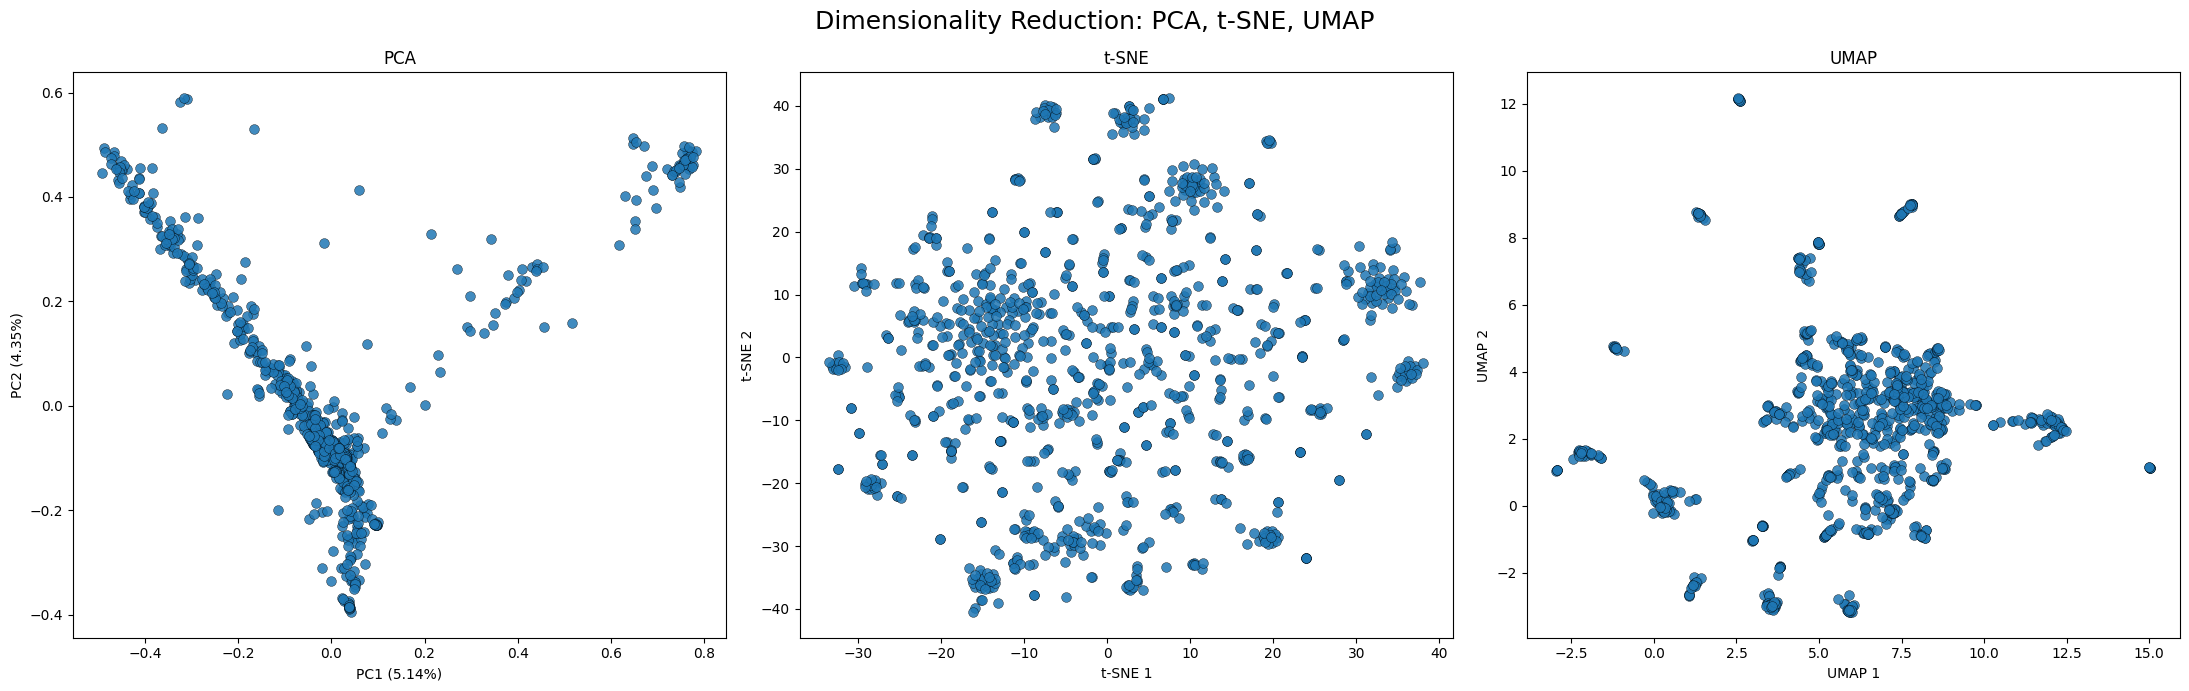

In [26]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_subsample)

# t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, n_jobs=N_JOBS)
pcs_tsne = tsne.fit_transform(X_subsample)

# UMAP
umap_model = umap.UMAP(n_components=2, random_state=RANDOM_SEED)
pcs_umap = umap_model.fit_transform(X_subsample)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
axes[0].scatter(pcs[:, 0], pcs[:, 1], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)
axes[0].set_title(f"PCA")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

axes[1].scatter(pcs_tsne[:, 0], pcs_tsne[:, 1], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)
axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

axes[2].scatter(pcs_umap[:, 0], pcs_umap[:, 1], s=50, alpha=0.85, edgecolor='k', linewidth=0.3)
axes[2].set_title("UMAP")
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")

plt.suptitle("Dimensionality Reduction: PCA, t-SNE, UMAP", fontsize=18)
plt.tight_layout()
plt.show()

---

## 3. Run Silhouette, Gap Statistic, Calinski Harabasz, and Davies Bouldin:

In [28]:
# # Prepare storage for metrics
# ks = np.arange(2, 11)
# silhouette_scores = []
# gap_scores = []
# calinski_scores = []
# davies_scores = []

# for k in ks:
#     kmeans = KMeans(n_clusters=k, random_state=RADNDOM_SEED)
#     labels = kmeans.fit_predict(X_pca_50)
    
#     # Silhouette
#     sil = silhouette_score(X_pca_50, labels)
#     silhouette_scores.append(sil)
    
#     # Gap Statistic
#     gap = gap_statistic(X_pca_50, labels, n_refs=10, algorithm=KMeans, random_state=RADNDOM_SEED)
#     gap_scores.append(gap)
    
#     # Calinski-Harabasz (scaled)
#     ch = calinski_harabasz_score(X_pca_50, labels)
#     calinski_scores.append(ch)
    
#     # Davies-Bouldin (inverted)
#     db = davies_bouldin_inv(X_pca_50, labels)
#     davies_scores.append(db)

# # Scale all scores to [0, 1]
# scaler = MinMaxScaler()
# silhouette_scores_scaled = scaler.fit_transform(np.array(silhouette_scores).reshape(-1, 1)).flatten()
# gap_scores_scaled = scaler.fit_transform(np.array(gap_scores).reshape(-1, 1)).flatten()
# calinski_scores_scaled = scaler.fit_transform(np.array(calinski_scores).reshape(-1, 1)).flatten()
# davies_scores_scaled = scaler.fit_transform(np.array(davies_scores).reshape(-1, 1)).flatten()

# # Find maxima for each metric
# max_sil_idx = np.argmax(silhouette_scores_scaled)
# max_gap_idx = np.argmax(gap_scores_scaled)
# max_ch_idx = np.argmax(calinski_scores_scaled)
# max_db_idx = np.argmax(davies_scores_scaled)

# plt.figure(figsize=(10, 8))
# plt.plot(ks, silhouette_scores_scaled, label='Silhouette', marker='o')
# plt.plot(ks, gap_scores_scaled, label='Gap Statistic', marker='o')
# plt.plot(ks, calinski_scores_scaled, label='Calinski-Harabasz', marker='o')
# plt.plot(ks, davies_scores_scaled, label='Davies-Bouldin (inverted)', marker='o')

# # Highlight maxima
# plt.scatter(ks[max_sil_idx], silhouette_scores_scaled[max_sil_idx], color='C0', s=120, edgecolor='k', zorder=5, label='Silhouette max')
# plt.scatter(ks[max_gap_idx], gap_scores_scaled[max_gap_idx], color='C1', s=120, edgecolor='k', zorder=5, label='Gap Statistic max')
# plt.scatter(ks[max_ch_idx], calinski_scores_scaled[max_ch_idx], color='C2', s=120, edgecolor='k', zorder=5, label='Calinski-Harabasz max')
# plt.scatter(ks[max_db_idx], davies_scores_scaled[max_db_idx], color='C3', s=120, edgecolor='k', zorder=5, label='Davies-Bouldin max')

# handles, labels_ = plt.gca().get_legend_handles_labels()
# filtered = [(h, l) for h, l in zip(handles, labels_) if "max" not in l]

# plt.xlabel('Number of clusters (k)')
# plt.ylabel('Score (scaled 0-1)')
# plt.title('Clustering metrics for KMeans (2-10 clusters)')
# plt.legend([h for h, _ in filtered], [l for _, l in filtered], bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

---

## 4. Run CARVE:

In [29]:
K = 100
ks = np.arange(2, K+1)

cfg = ValidatorConfig(
    X=X_subsample,
)

val = CARVE(cfg)
val.validate(random_state=RANDOM_SEED)

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

KeyboardInterrupt: 

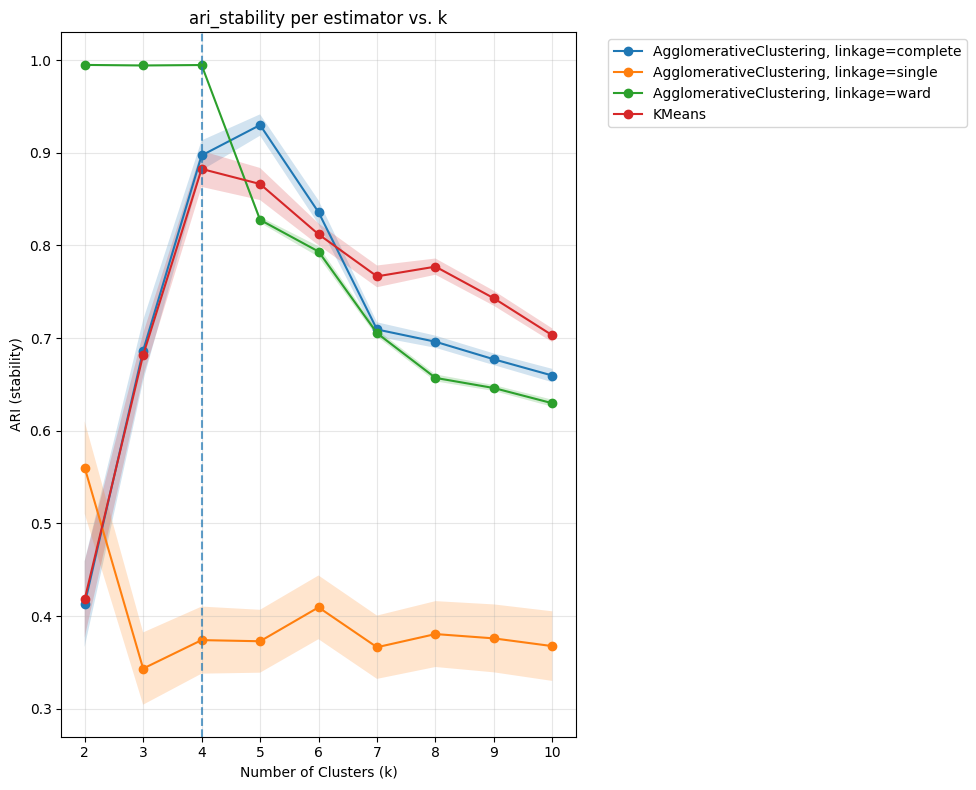

In [60]:
val.plot_results(measure='ari_stability', rule='1se', interactive=False)

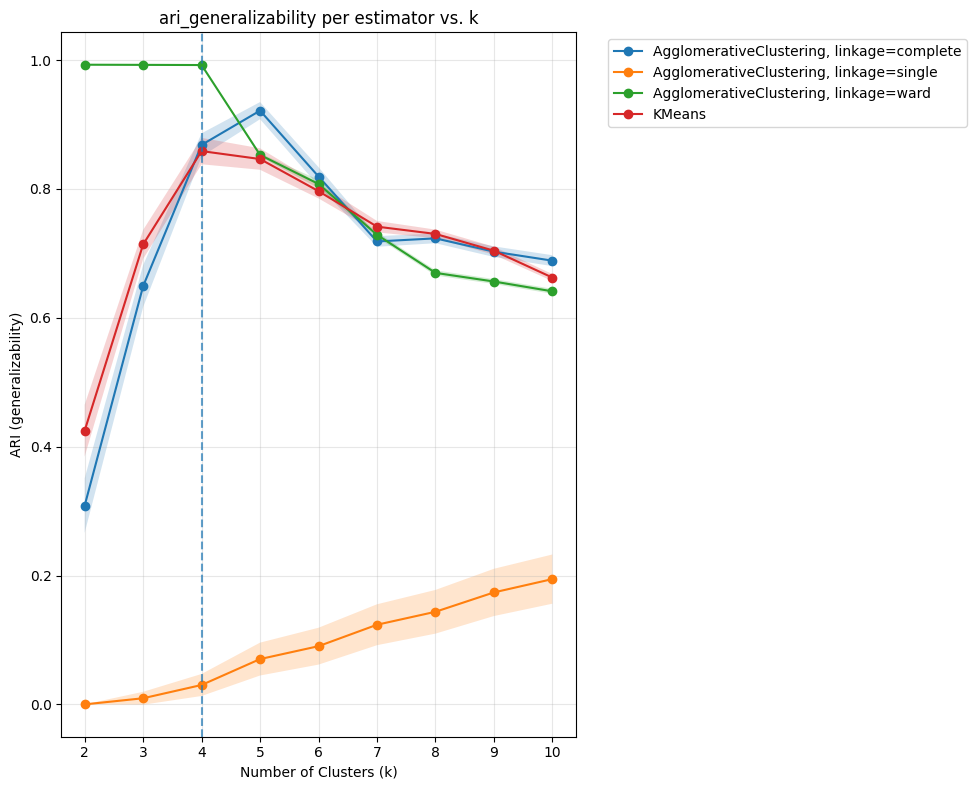

In [61]:
val.plot_results(measure='ari_generalizability', rule='1se', interactive=False)

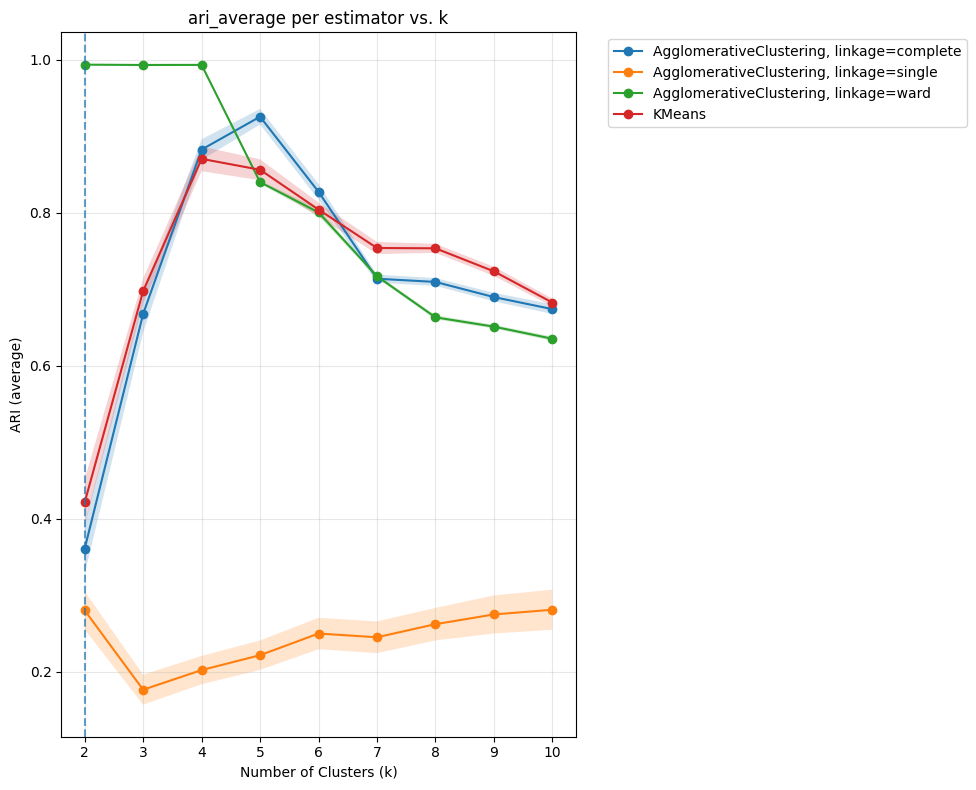

In [72]:
val.plot_results(measure='ari_average', rule='max', interactive=False)

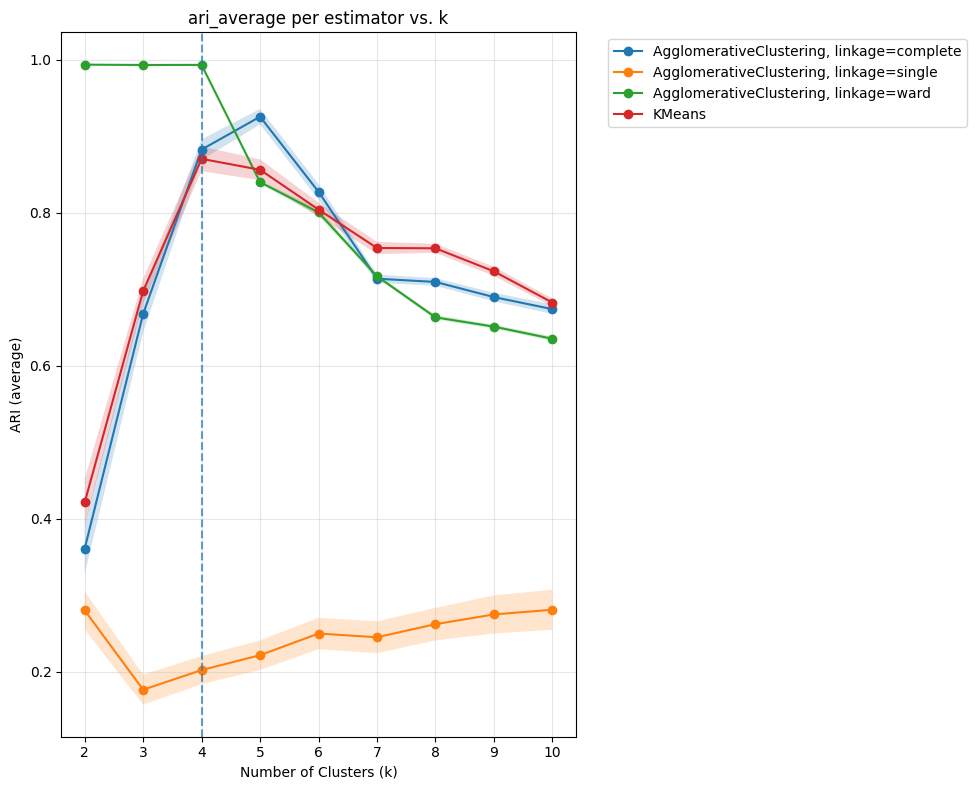

In [73]:
val.plot_results(measure='ari_average', rule='1se', interactive=False)

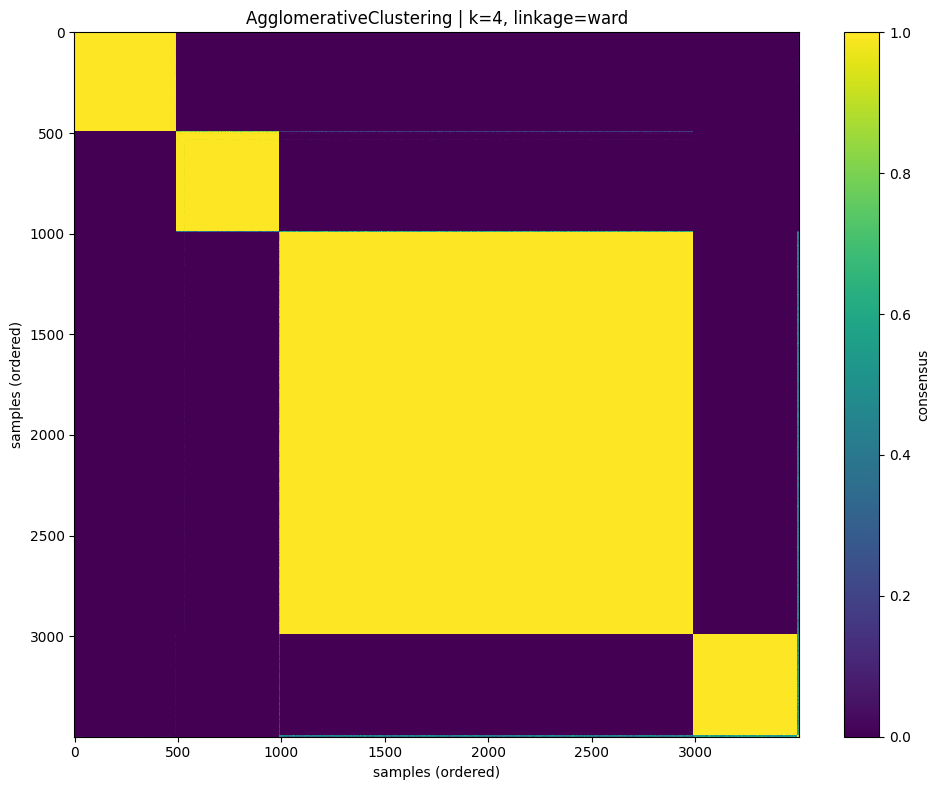

In [63]:
val.plot_consensus_matrix(measure='ari_stability', rule='1se')

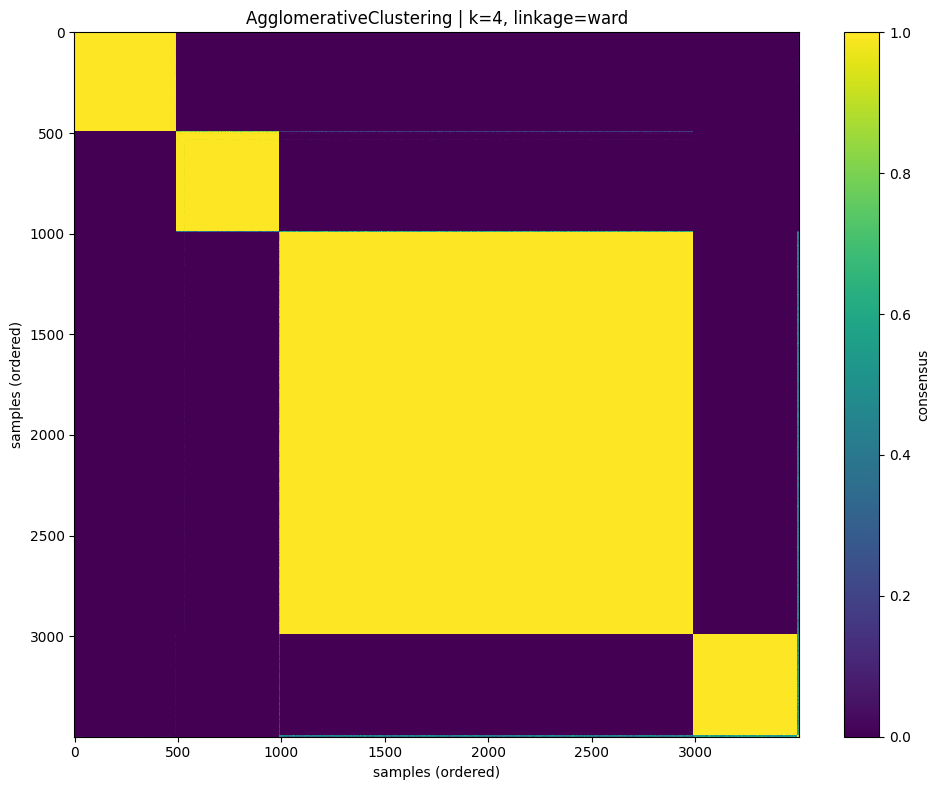

In [64]:
val.plot_consensus_matrix(measure='ari_generalizability', rule='1se')

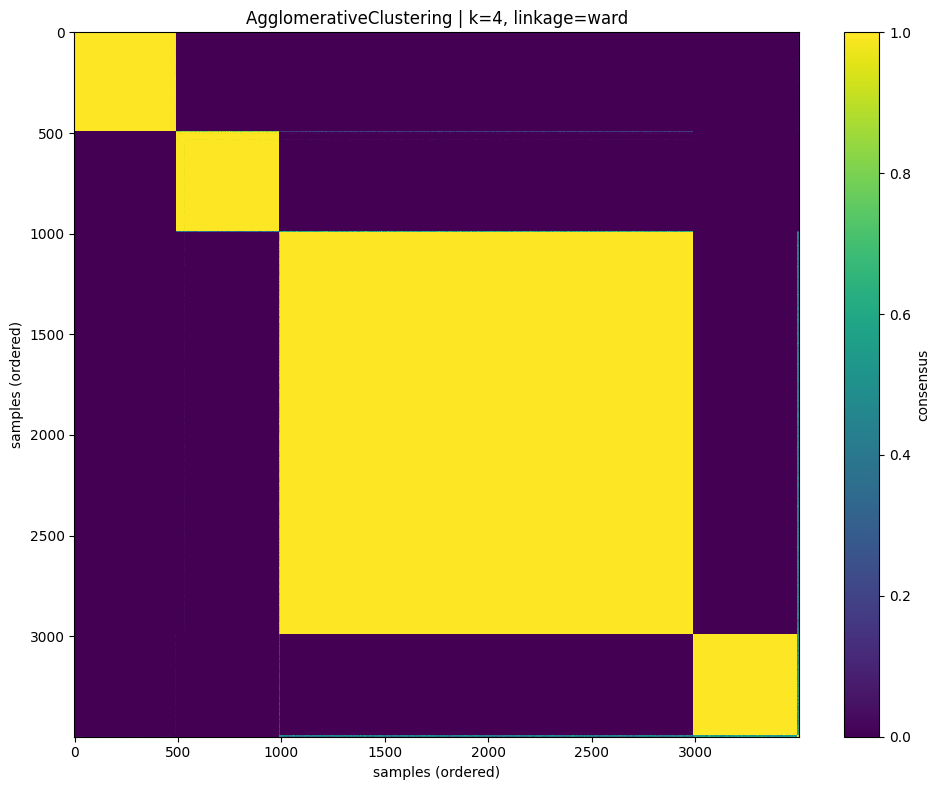

In [65]:
val.plot_consensus_matrix(measure='ari_average', rule='1se')

In [66]:
val.plot_clustering(k=4, measure='ari_stability', rule='1se', interactive=True)

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAP' ... 'Cjixfg7z/42y0vJ97vPwAAAAAAAPA/'),
                             'dtype': 'f8',
                             'shape': '2006, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.3,
                         'size': {'bdata': ('T0lCndrFKkD9e+Jg5cUqQCLsjzMBxi' ... 'IzxipAuM0XYA3HKkB58emDxMUqQA=='),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': '968e783f-5612-40da-ade7-eb49ef513cf2',
              'x': {'bdata': ('ygY8wL3UP8D+YRXAuo8vwBnHZMBgh3' ... 'fA3yFAwHjNPsAPkYfAL+kcwGKl6L4='),
                

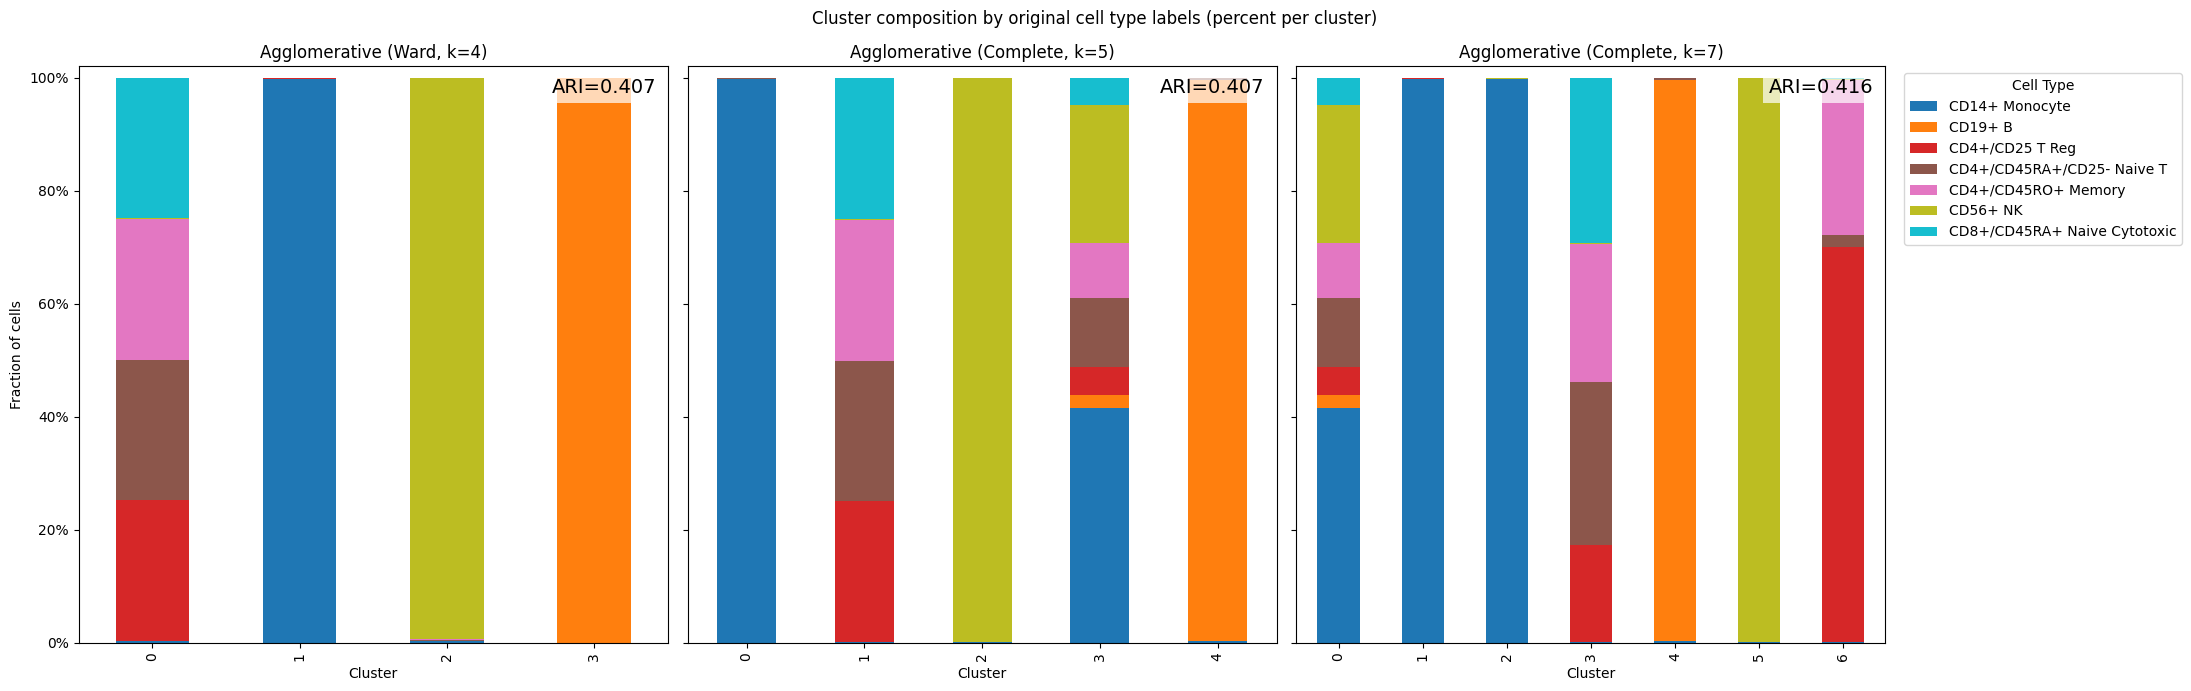

In [74]:
def cluster_composition_percent(labels, y, categories):
    comp = []
    for i in range(len(np.unique(labels))):
        idx = np.where(labels == i)[0]
        counts = Counter(y[idx])
        total = sum(counts.get(cat, 0) for cat in categories)
        comp.append([counts.get(cat, 0) / total if total > 0 else 0 for cat in categories])
    return pd.DataFrame(comp, columns=categories)

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
categories = y.categories

# Agglomerative k=4 (Ward)
agg4 = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg4 = agg4.fit_predict(X_pca_50)
df_agg4 = cluster_composition_percent(labels_agg4, y, categories)
df_agg4.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', legend=False)
axes[0].set_title('Agglomerative (Ward, k=4)')
axes[0].set_ylabel('Fraction of cells')
axes[0].set_ylim(0, 1.02)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))

# AgglomerativeClustering k=5 (complete)
agg5 = AgglomerativeClustering(n_clusters=5, linkage='complete')
labels_agg5 = agg5.fit_predict(X_pca_50)
df_agg5 = cluster_composition_percent(labels_agg5, y, categories)
df_agg5.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', legend=False)
axes[1].set_title('Agglomerative (Complete, k=5)')
axes[1].set_ylim(0, 1.02)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))

# AgglomerativeClustering k=7 (complete)
agg7 = AgglomerativeClustering(n_clusters=7, linkage='complete')
labels_agg7 = agg7.fit_predict(X_pca_50)
df_agg7 = cluster_composition_percent(labels_agg7, y, categories)
df_agg7.plot(kind='bar', stacked=True, ax=axes[2], colormap='tab10', legend=True)
axes[2].set_title('Agglomerative (Complete, k=7)')
axes[2].set_ylim(0, 1.02)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x*100)}%"))

axes[0].set_xlabel('Cluster')
axes[1].set_xlabel('Cluster')
axes[2].set_xlabel('Cluster')
axes[2].legend(title='Cell Type', bbox_to_anchor=(1.02, 1), loc='upper left')

# Show ARI scores
ari_agg4 = adjusted_rand_score(y, labels_agg4)
ari_kmeans5 = adjusted_rand_score(y, labels_agg5)
ari_kmeans7 = adjusted_rand_score(y, labels_agg7)
axes[0].text(0.98, 0.98, f"ARI={ari_agg4:.3f}", ha='right', va='top', transform=axes[0].transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[1].text(0.98, 0.98, f"ARI={ari_kmeans5:.3f}", ha='right', va='top', transform=axes[1].transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
axes[2].text(0.98, 0.98, f"ARI={ari_kmeans7:.3f}", ha='right', va='top', transform=axes[2].transAxes, fontsize=14, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.suptitle('Cluster composition by original cell type labels (percent per cluster)')
plt.tight_layout()
plt.show()

---